## 1.	Постановка задачі (Варіант 1-1-10).
I.	  Теоретична частина.
Вивчити теоретичні положення згідно переліку питань до лабораторної роботи № 1

II.	  Практична частина.
Створити програму, яка б для заданого часового ряду дозволяла:
1.	Відобразити ряд динаміки графічно.
2.	Перевірити ряд на випадковість:

    2.1. Метод знаків.
3.	Реалізувати методи:

    3.1. Метод Манна.
4.	Побудувати корелограму до та після перевірки коефіцієнтів кореляції на значимість, на базі якої зробити висновок про наявність сезонної складової та тренду.
5.	Виділити лінійний тренд, побудувати графік залишків, перевірити ряд залишків на випадковість.

III.	  Оформлення звіту.
Звіт з лабораторної роботи складається з таких частин
1.	Постановка задачі (з урахуванням індивідуального завдання).
2.	Опис програми (порядок роботи з програмою, опис формату вхідних даних та додаткових можливостей програми).
3.	Реалізація (вхідні дані повністю, вихідні результати у вигляді графіків та  таблиць).
4.	Відповіді на питання.
5.	Висновки (коментарі та пояснення щодо отриманих результатів реалізації індивідуального завдання).


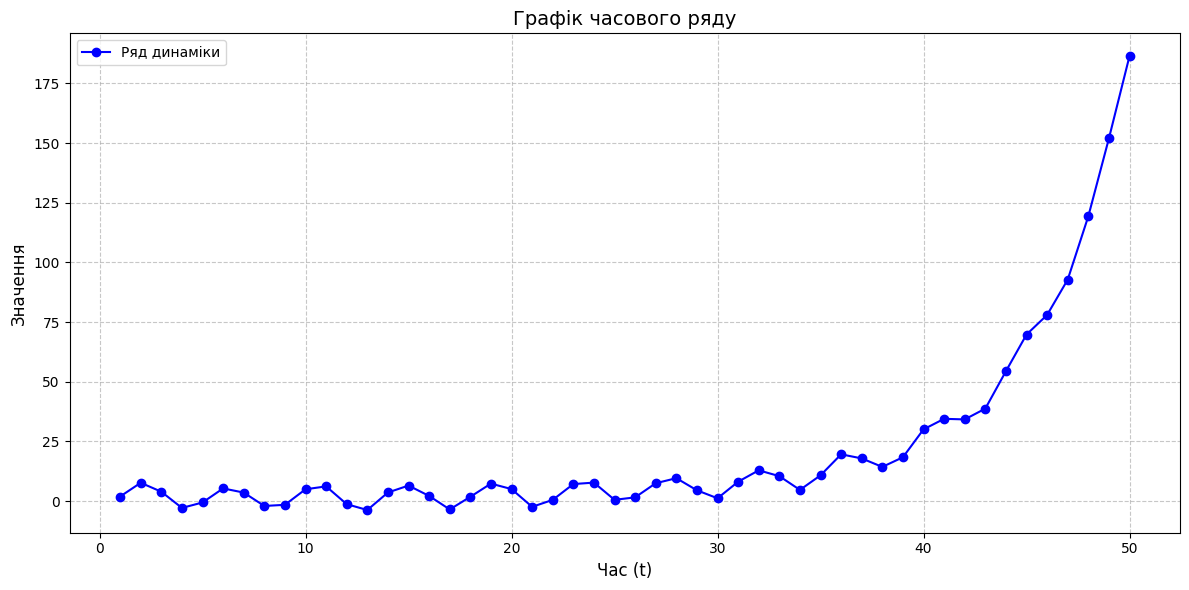
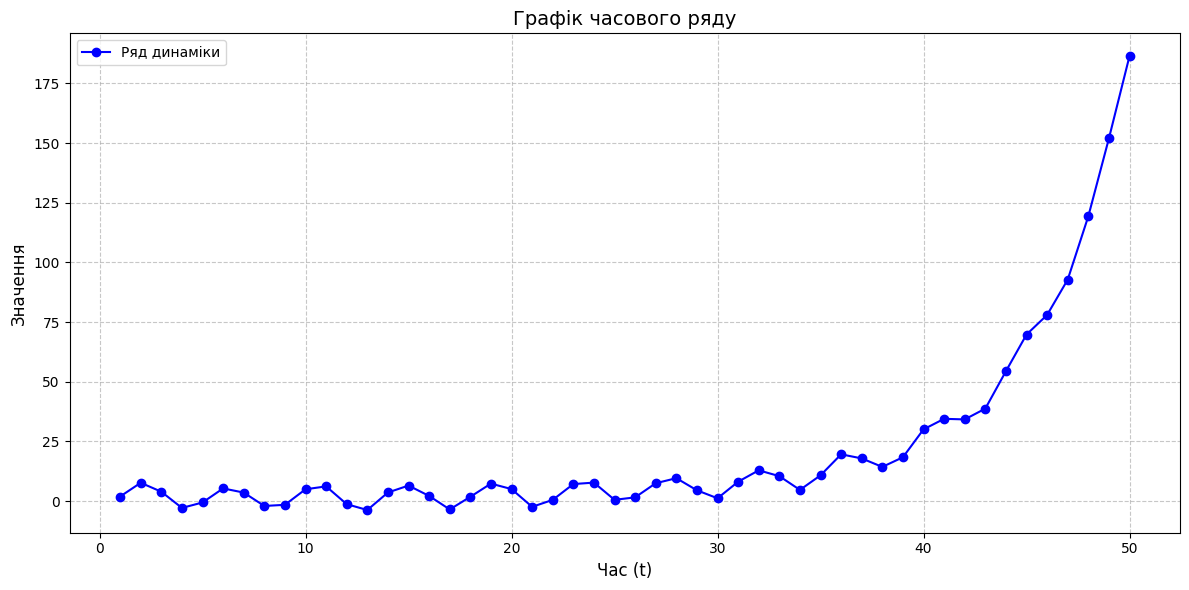
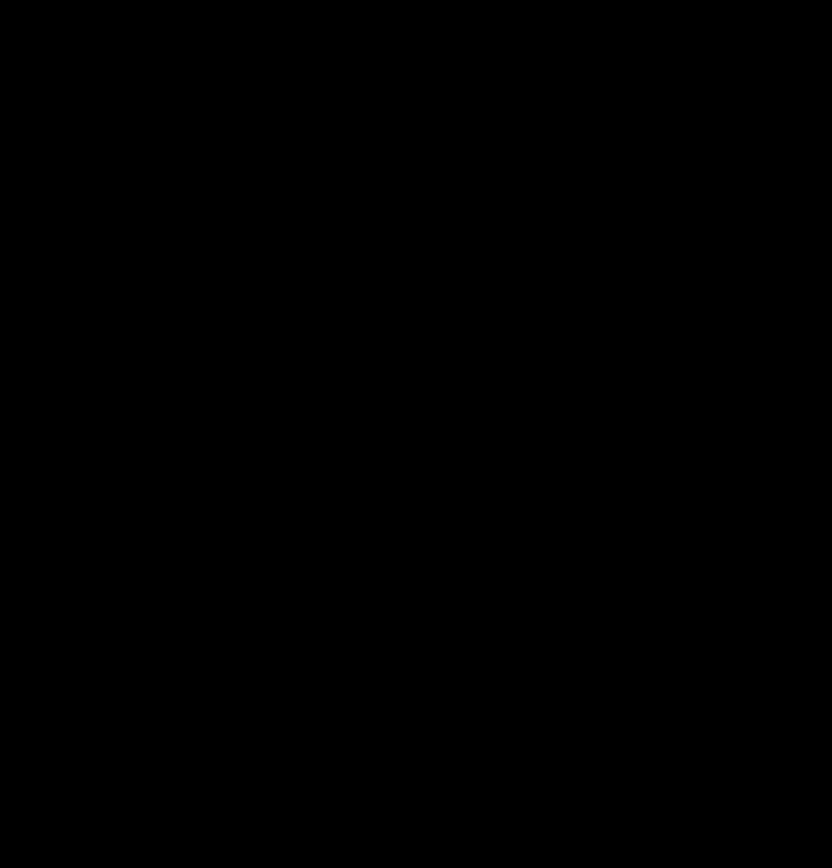

## 2. Опис програми

**Порядок роботи з програмою:**
1. Запустити комірку імпорту необхідних бібліотек.
2. Запустити комірку вибору файлу. Обрати файл з даними (допустимі формати: CSV, Excel, TXT).
3. Послідовно виконувати наступні комірки для візуалізації вхідного часового ряду. Всі графіки будуються автоматично.
4. Запустити комірки статистичних метрик. Переглянути тексти висновків щодо випадковості, наявності тренду тощо.

**Опис формату вхідних даних:**
* Програма зчитує дані з текстових чи табличних файлів.
* Елементи у файлі мають бути розділені пробільними символами (sep='\s+').
* Зчитані дані формуються в об'єкт DataFrame. В алгоритмі для отримання часового ряду береться перший рядок з файлу (через .iloc[0]). Якщо ж значення у файлі зберігаються по стовпцях, то індексацію необхідно змінити.


## 3. Реалізація


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import pymannkendall as mk
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
import tkinter as tk
from tkinter import filedialog
import math

In [ ]:
root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename(title="Оберіть файл з даними", filetypes=[("CSV files", "*.csv"), ("Excel files", "*.xlsx"), ("TXT files", "*.txt")])

In [3]:
time_series = pd.read_csv(file_path, sep='\s+', header=None)
time_series

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.88,7.64,3.89,-2.9,-0.62,5.28,3.53,-2.08,-1.6,4.92,...,34.45,34.2,38.73,54.41,69.78,78.0,92.81,119.36,152.0,186.51


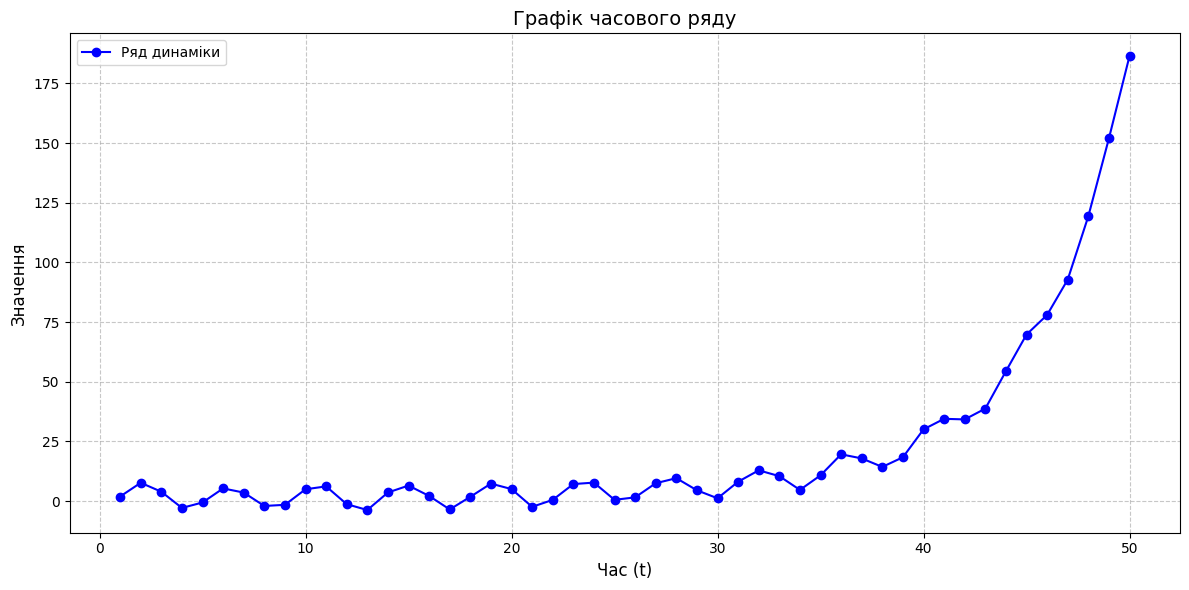

In [5]:
series = time_series.iloc[0]
N = len(series)
alpha = 0.05
u_crit = stats.norm.ppf(1 - alpha / 2)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(series) + 1), series, marker='o', linestyle='-', color='b', label='Ряд динаміки')

plt.title('Графік часового ряду', fontsize=14)
plt.xlabel('Час (t)', fontsize=12)
plt.ylabel('Значення', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def check_signs(y):
    C = 0
    for i in range(N - 1):
        if y[i] < y[i + 1]:
            C += 1

    M = (N - 1) / 2
    D = (N + 1) / 12
    K = (C - M) / math.sqrt(D)
    print(f"C: {C}, M: {M}, D: {D}, K: {K}")

    print(f"Статистика K = {K:.4f}")
    print(f"Критичне значення u = {u_crit:.4f}")

    if abs(K) <= u_crit:
        print("Висновок: |K| <= u — приймається гіпотеза H0 (ряд є випадковим).")
    elif K < -u_crit:
        print("Висновок: K < -u — приймається гіпотеза H1 (наявний тренд з тенденцією до спадання).")
    else:
        print("Висновок: K > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).")

def check_mann(y):
    h = np.zeros([N, N])

    for i in range(N - 1):
        for j in range(i + 1, N):
            if y[i] < y[j]:
                h[i][j] = 1
            elif y[i] > y[j]:
                h[i][j] = 0
            else:
                h[i][j] = 0.5

    T = np.sum(h)
    M = N * (N - 1) / 2 * 0.5
    D = (2 * N + 5) * N * (N - 1) / 72
    U = (T - M + 0.5) / math.sqrt(D)

    print(f"Статистика K = {U:.4f}")
    print(f"Критичне значення u = {u_crit:.4f}")

    if abs(U) <= u_crit:
        print("Висновок: |U| <= u — приймається гіпотеза H0 (ряд є випадковим).")
    elif U < -u_crit:
        print("Висновок: U < -u — приймається гіпотеза H1 (наявний тренд з тенденцією до спадання).")
    else:
        print("Висновок: U > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).")

In [7]:
check_signs(series)

C: 31, M: 24.5, D: 4.25, K: 3.1529631254723287
Статистика K = 3.1530
Критичне значення u = 1.9600
Висновок: K > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).


In [8]:
check_mann(series)

Статистика K = 6.7923
Критичне значення u = 1.9600
Висновок: U > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).


In [9]:
rs_before = []
rs_after = []
ts = []

k_max = math.ceil(N / 2)
u_mean = np.mean(series)

denominator_sum = np.sum((series - u_mean)**2)

for k in range(1, k_max + 1):
    numerator_sum = 0
    for i in range(N - k):
        numerator_sum += (series[i] - u_mean) * (series[i + k] - u_mean)

    r = numerator_sum / (N - k) / (denominator_sum / N)
    rs_before.append(r)

    v = N - k - 2
    t = r * math.sqrt(v) / math.sqrt(1 - r**2)
    ts.append(t)

    t_crit = stats.t.ppf(1 - alpha / 2, df=v)
    if abs(t) <= t_crit:
        rs_after.append(0.0)
    else:
        rs_after.append(r)

,Лаг (k),rs_k (до перевірки),Статистика t_k,rs_k (після перевірки)
0,1,0.8088,9.4299,0.8088
1,2,0.6457,5.7347,0.6457
2,3,0.5313,4.2066,0.5313
3,4,0.4521,3.3620,0.4521
4,5,0.3707,2.6174,0.3707
5,6,0.2799,1.8898,0.0000
6,7,0.2194,1.4399,0.0000
7,8,0.1945,1.2544,0.0000
8,9,0.1618,1.0242,0.0000
9,10,0.1065,0.6604,0.0000


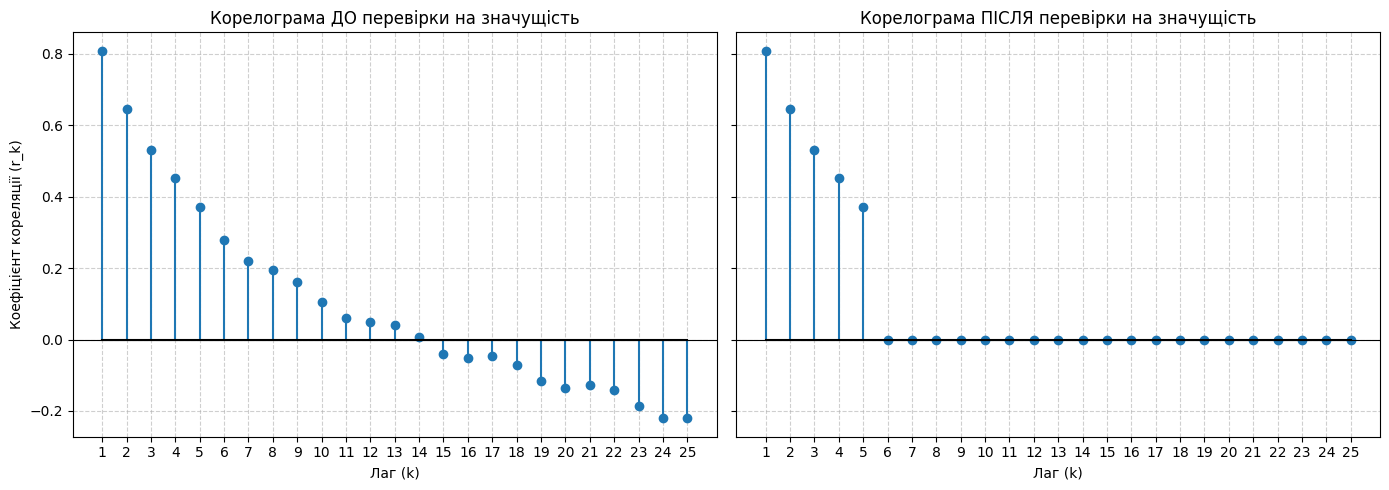

In [10]:
lags = list(range(1, k_max + 1))

df_corr = pd.DataFrame({
    'Лаг (k)': lags,
    'rs_k (до перевірки)': np.round(rs_before, 4),
    'Статистика t_k': np.round(ts, 4),
    'rs_k (після перевірки)': np.round(rs_after, 4)
})
display(df_corr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].stem(lags, rs_before, basefmt="black")
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Корелограма ДО перевірки на значущість')
axes[0].set_xlabel('Лаг (k)')
axes[0].set_ylabel('Коефіцієнт кореляції (r_k)')
axes[0].set_xticks(lags)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].stem(lags, rs_after, basefmt="black")
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Корелограма ПІСЛЯ перевірки на значущість')
axes[1].set_xlabel('Лаг (k)')
axes[1].set_xticks(lags)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

На корелограмі після перевірки на значущість перші 5 коефіцієнтів автокореляції  є статистично значущими, додатними та плавно монотонно спадають зі збільшенням лагу $k$. Це є прямою ознакою наявності не випадкової складової - тренду в часовому ряді.
Починаючи з лагу $k = 6$ і до $k = 25$, усі коефіцієнти виявилися статистично незначущими. Оскільки на графіку відсутні періодичні сплески, сезонна складова в ряді відсутня.

Рівняння лінійного тренду: y(t) = 1.8815 * t + -26.2134


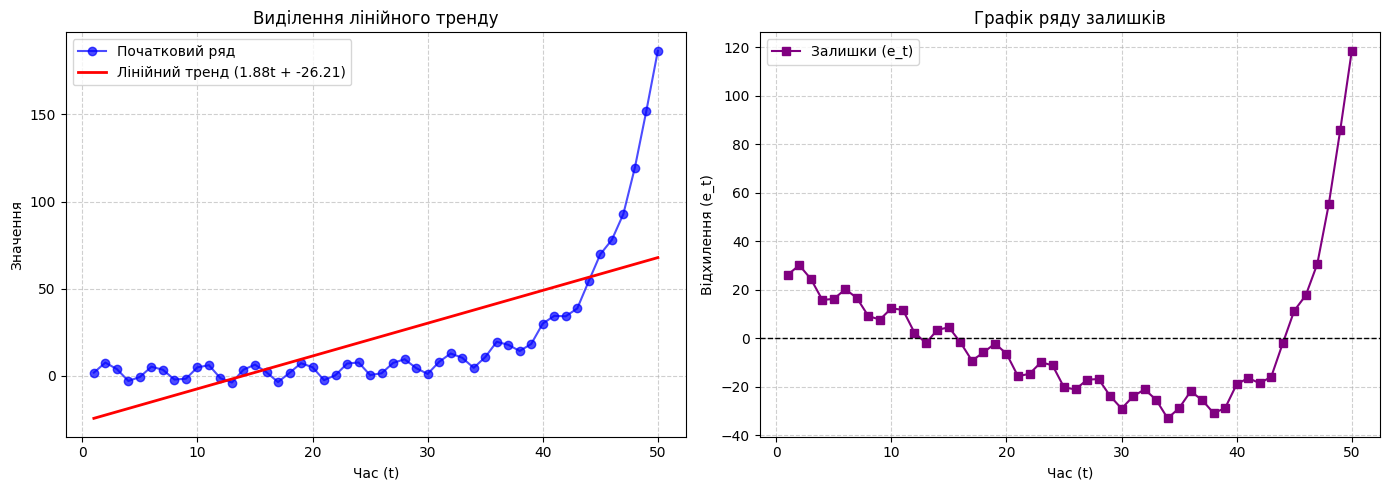

In [11]:
t_index = np.arange(1, N + 1)

a, b = np.polyfit(t_index, series, 1)
trend = a * t_index + b

residuals = series - trend

print(f"Рівняння лінійного тренду: y(t) = {a:.4f} * t + {b:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(t_index, series, marker='o', label='Початковий ряд', color='blue', alpha=0.7)
axes[0].plot(t_index, trend, color='red', linewidth=2, label=f'Лінійний тренд ({a:.2f}t + {b:.2f})')
axes[0].set_title('Виділення лінійного тренду')
axes[0].set_xlabel('Час (t)')
axes[0].set_ylabel('Значення')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

axes[1].plot(t_index, residuals, marker='s', color='purple', linestyle='-', label='Залишки (e_t)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Графік ряду залишків')
axes[1].set_xlabel('Час (t)')
axes[1].set_ylabel('Відхилення (e_t)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
check_signs(residuals)

C: 27, M: 24.5, D: 4.25, K: 1.212678125181665
Статистика K = 1.2127
Критичне значення u = 1.9600
Висновок: |K| <= u — приймається гіпотеза H0 (ряд є випадковим).


In [13]:
check_mann(residuals)

Статистика K = -3.4463
Критичне значення u = 1.9600
Висновок: U < -u — приймається гіпотеза H1 (наявний тренд з тенденцією до спадання).


## 4. Відповіді на питання

### 1. Що таке «часовий ряд»?

**Часовий ряд (ряд динаміки)** — це впорядкована в часі послідовність спостережень (значень) деякого показника або випадкової величини $u_1, u_2, \dots, u_N$, виміряних у послідовні моменти часу $t_1 < t_2 < \dots < t_N$ (найчастіше через рівні проміжки часу $\Delta t$). Кожен елемент ряду $u_t$ називається рівнем ряду.

### 2. Чим часовий ряд відрізняється від вибірки?

* **Критичність порядку елементів:** У класичній статистичній вибірці порядок елементів не має значення (їх можна переставляти місцями, від цього вибіркові характеристики не зміняться). У часовому ряді кожне значення жорстко прив'язане до свого моменту часу $t$, і зміна порядку руйнує структуру даних.
* **Статистична залежність:** Елементи випадкової вибірки вважаються незалежними та однаково розподіленими. У часовому ряді сусідні спостереження зазвичай статистично залежні між собою (наявна автокореляція) та можуть мати змінні в часі математичне очікування й дисперсію.

### 3. Як можна отримати часовий ряд $v_t$, якщо початковий ряд даних $u_t$?

*(У тексті методички формули були об'єктами Equation, тому нижче наведено обидва стандартні варіанти відповіді залежно від контексту лекції)*:

1. **Якщо йдеться про вилучення тренду (перехід до похідного ряду приростів):** Новий ряд отримують шляхом взяття скінченних різниць першого порядку $v_t = \Delta u_t = u_{t+1} - u_t$ (або вищих порядків), а також шляхом центрування ($v_t = u_t - \bar{u}$) чи виділення залишків після віднімання тренду ($e_t = u_t - \hat{u}_t$).
2. **Якщо початкові відліки нерівномірні або містять пропуски:** Часовий ряд із рівним кроком дискретизації $\Delta t$ отримують шляхом агрегації (усереднення або сумування значень усередині однакових часових інтервалів) або інтерполяції (відновлення проміжних значень у фіксовані моменти часу).

### 4. Назвіть задачі аналізу часових рядів.

1. **Візуалізація та попередній опис** динаміки досліджуваного процесу.
2. **Перевірка ряду на випадковість та стаціонарність** за допомогою статистичних критеріїв.


3. **Декомпозиція (виявлення структури ряду)** — виділення детермінованих складових: тренду, сезонної та циклічної компонент, а також відокремлення випадкового шуму.
4. **Згладжування та фільтрація** — усунення високочастотних випадкових коливань для чіткішого виявлення тенденції.
5. **Математичне моделювання та прогнозування (екстраполяція)** майбутніх значень ряду на основі його минулої поведінки.

### 5. Які часові ряди розглядає математична статистика?

Математична статистика розглядає часові ряди як реалізації випадкових (стохастичних) процесів і класифікує їх за такими ознаками:

* **За часом:** дискретні (значення фіксуються в окремі моменти часу $t_i$) та неперервні.
* **За стабільністю характеристик:** стаціонарні та нестаціонарні.
* **За наявністю закономірностей:** суто випадкові («білий шум») та невипадкові (ті, що містять детерміновану складову або автокореляцію).


* **За розмірністю:** одномірні (один показник) та багатовимірні (система взаємозалежних показників).

### 6. Як математично можна представити часовий ряд? Які Ви знаєте складові часового ряду?

Математично рівні часового ряду $u_t$ представляють як комбінацію чотирьох основних складових у вигляді **адитивної** або **мультиплікативної** моделі:

* **Адитивна модель:** $u_t = T_t + S_t + C_t + E_t$ (використовується, коли амплітуда сезонних коливань майже не змінюється з часом).
* **Мультиплікативна модель:** $u_t = T_t \cdot S_t \cdot C_t \cdot E_t$ (використовується, коли амплітуда коливань зростає або спадає пропорційно до рівня тренду).

**Складові часового ряду:**

1. **Тренд ($T_t$)** — плавна довгострокова детермінована тенденція до зростання або спадання ряду.
2. **Сезонна складова ($S_t$)** — строго періодичні коливання, пов'язані з календарними або фізичними циклами фіксованої тривалості (доба, тиждень, квартал, рік).
3. **Циклічна складова ($C_t$)** — тривалі коливання навколо тренду з нефіксованим періодом (наприклад, економічні або демографічні хвилі).
4. **Випадкова (залишкова) складова ($E_t$ або $\varepsilon_t$)** — непередбачувані стохастичні збурення («шум»), зумовлені дією великої кількості дрібних випадкових факторів.

### 7. Що таке квантіль розподілу?

**Квантіль розподілу порядку $p$** ($0 < p < 1$) — це таке значення випадкової величини $x_p$, яке ділить розподіл імовірностей на дві частини у заданій пропорції: ймовірність того, що випадкова величина $X$ набуде значення, меншого або рівного $x_p$, дорівнює $p$:


$$F(x_p) = P(X \le x_p) = p$$


У перевірці двосторонніх статистичних гіпотез при рівні значущості $\alpha = 0.05$ використовується критичний квантиль стандартного нормального розподілу порядку $1 - \alpha/2 = 0.975$, який дорівнює $u_{\alpha/2} = 1.96$.

### 8. Навіщо нормується статистика, яка має нормальний розподіл?

Початкові статистики критеріїв (наприклад, кількість точок росту $C$ у методі знаків або сума інверсій $T_n$ у методі Манна) при великих $N$ розподілені за нормальним законом $N(M, D)$, але їхні математичне очікування $M$ та дисперсія $D$ залежать від довжини ряду $N$.
Нормування за формулою $Z = \frac{\text{Статистика} - M}{\sqrt{D}}$ переводить будь-який нормальний розподіл $N(M, D)$ у **стандартний нормальний розподіл $N(0, 1)$** з математичним очікуванням $0$ і дисперсією $1$. Це дозволяє порівнювати отриману статистику з єдиними універсальними табличними квантилями (наприклад, $u_{\alpha/2} = 1.96$) для ряду будь-якої довжини $N$.

### 9. В чому суть Ваших методів? Чим відрізняються інші методи від Ваших?

**Суть методів індивідуального варіанта:**

* **Метод знаків (критерій знаків різниць):** досліджує знаки приростів між сусідніми елементами ряду ($u_i < u_{i+1}$) та підраховує кількість «точок росту» $C = \sum_{i=1}^{N-1} x_i$. Якщо ряд випадковий, кількість додатних і від'ємних приростів приблизно однакова ($M\{C\} = \frac{N-1}{2}$). Суттєвий перекіс свідчить про наявність тренду.


* **Метод Манна (ранговий критерій):** порівнює кожен рівень ряду з **усіма наступними** ($u_i$ та $u_j$ при $i < j$) за допомогою матриці індикаторів $h_{i,j}$. Статистика $T_n = \sum_{i=1}^{N-1}\sum_{j=i+1}^N h_{i,j}$ узагальнює кількість пар, що зростають, у межах усього ряду, що дозволяє надійно виявляти глобальний монотонний тренд.



**Відмінності інших методів:**

* **Метод екстремальних (поворотних) точок:** аналізує трійки сусідніх значень і рахує локальні піки та западини ($u_{i-1} < u_i > u_{i+1}$ або $u_{i-1} > u_i < u_{i+1}$). На відміну від наших методів, він найкраще виявляє **циклічність (періодичні коливання)**, а не монотонний тренд.
* **Метод Спірмена:** також базується на матриці індикаторів $h_{i,j}$, але додатково зважує кожне порівняння на відстань між індексами часу $(j - i)$ (оцінює рангову кореляцію між рівнями ряду та часом). Має зворотне правило знаків: додатні значення перевищення квантиля свідчать про спадання, а від'ємні — про зростання.
* **Метод рекордних значень (Фостера–Стюарта):** порівнює поточний елемент з усіма *попередніми* від початку ряду, фіксуючи лише ті точки, які побили попередній абсолютний максимум або мінімум. Дозволяє одночасно перевіряти як тренд середнього рівня, так і тренд дисперсії (розширення чи звуження розмаху коливань).

### 10. Що таке корелограма, та які висновки можна зробити при її аналізі?

**Корелограма** — це графік залежності коефіцієнтів автокореляції (серіальної кореляції) $r_k$ від величини часового зсуву (лагу) $k = 1, 2, \dots, k_{\max}$.
Висновки, які роблять після перевірки коефіцієнтів $r_k$ на статистичну значущість за критерієм Стьюдента:

1. Якщо всі коефіцієнти $r_k$ статистично незначущі (після перевірки дорівнюють $0$) — ряд є **випадковим**, тренд і сезонність відсутні.
2. Якщо перші кілька лагів ($k = 1, 2, 3\dots$) мають високі значущі додатні коефіцієнти, які плавно монотонно спадають зі збільшенням лагу — у ряді наявний **тренд**.


3. Якщо на корелограмі спостерігаються значущі піки, що повторюються через однакові інтервали лагів ($k = \tau, 2\tau, 3\tau\dots$) — ряд містить **сезонну (циклічну) складову** з періодом $\tau$.

### 11. Що таке тренд?

**Тренд** — це плавна детермінована складова часового ряду, яка описує основну довгострокову тенденцію розвитку процесу (систематичне зростання або спадання середнього значення ряду з плином часу) без урахування сезонних коливань та випадкових збурень.

### 12. Що являє собою стаціонарний (нестаціонарний) ряд, випадковий (невипадковий) ряд?

* **Стаціонарний ряд (у широкому сенсі)** — це часовий ряд, статистичні властивості якого інваріантні відносно часу: його математичне очікування $M\{u_t\} = \text{const}$ та дисперсія $D\{u_t\} = \text{const}$ є постійними, а автокореляція між двома рівнями залежить виключно від величини лагу $k$ між ними, а не від моменту часу $t$. **Нестаціонарний ряд** — ряд, у якого середній рівень (через тренд чи сезонність) або дисперсія змінюються в часі.
* **Випадковий ряд («білий шум»)** — послідовність взаємно незалежних та однаково розподілених випадкових величин, у якій відсутні детерміновані компоненти (тренд, циклічність) та автокореляція ($r_k = 0$ при $k \ge 1$). **Невипадковий ряд** — ряд, рівні якого залежать від часу (наявний тренд або сезонність) або від попередніх значень ряду.



### 13. Яка гіпотеза перевіряється при реалізації Ваших методів?

У методах перевірки ряду на випадковість висувається:

* **Нульова гіпотеза ($H_0$):** досліджуваний часовий ряд є **випадковим** (тренд відсутній, спостереження незалежні). Приймається, якщо модуль нормованої статистики не перевищує критичний квантиль: $\vert{}K\vert{} \le u_{\alpha/2}$ (або $\vert{}U\vert{} \le u_{\alpha/2}$).


* **Альтернативна гіпотеза ($H_1$):** ряд є невипадковим — у ряді **наявний тренд**:


* якщо статистика $> u_{\alpha/2}$ — наявний тренд із тенденцією до **зростання**;


* якщо статистика $< -u_{\alpha/2}$ — наявний тренд із тенденцією до **спадання**.




* При побудові корелограми для кожного лагу $k$ за критерієм Стьюдента перевіряється гіпотеза $H_0: r_k = 0$ (коефіцієнт автокореляції статистично незначущий) проти $H_1: r_k \neq 0$.



### 14. Порівняйте потужності різних критеріїв.

**Потужність критерію** — це ймовірність правильно відхилити нульову гіпотезу про випадковість ряду, коли тренд або циклічність реально існують ($1 - \beta$, де $\beta$ — імовірність помилки другого роду).

* **Локальні критерії (метод знаків та метод екстремальних точок)** мають **найменшу потужність** для виявлення тренду. Вони враховують лише напрямок зміни між сусідніми точками ($N-1$ порівнянь) і повністю ігнорують як абсолютну величину приростів, так і загальну поведінку ряду на великих проміжках.


* **Метод рекордних значень** має середню потужність: він добре працює на коротких рядах, але на довгих вибірках його чутливість падає, оскільки нові рекорди трапляються дедалі рідше, а один випадковий викид на початку ряду може заблокувати фіксацію наступних рекордів.
* **Рангові критерії (метод Манна та метод Спірмена)** мають **найвищу потужність** серед непараметричних методів при виявленні монотонного тренду (їхня асимптотична ефективність досягає ~91–95% відносно параметричних критеріїв). Це зумовлено тим, що вони аналізують глобальну структуру ряду, порівнюючи кожен елемент з усіма наступними ($\frac{N(N-1)}{2}$ пар). Саме тому в нашій роботі при перевірці ряду залишків слабкий метод знаків прийняв гіпотезу $H_0$ ($\vert{}K\vert{} = 1.21 \le 1.96$), а потужніший критерій Манна впевнено виявив залишковий нелінійний тренд ($\vert{}U\vert{} = 3.45 > 1.96$).

## 5. Висновки
Після вилучення лінійного тренду $\hat{y}(t) = 1.88t - 26.21$ отриманий ряд залишків було перевірено на випадковість двома методами. За методом знаків ($\vert{}K\vert{} = 1.2127 \le 1.96$) гіпотеза про випадковість формально приймається через низьку потужність критерію, який враховує лише знаки локальних приростів між сусідніми точками.   За більш потужним ранговим критерієм Манна ($\vert{}U\vert{} = 3.4463 > 1.96$) гіпотеза про випадковість відхиляється - у залишках виявлено статистично значущу тенденцію (спадання на проміжку $t \in [1; 38]$). Оскільки ряд залишків не є випадковим і на графіку має чітку параболічну/експоненційну форму, лінійний тренд не описує детерміновану складову часового ряду. Досліджуваний часовий ряд містить нелінійний тренд.